# Phân tích Ảnh hưởng của Khác biệt GPU đến Tính chính xác Mô hình

**Mục tiêu**: 
- Phân tích kết quả thực nghiệm từ thư mục `results/` để hiểu ảnh hưởng của khác biệt GPU và cấu hình đến tính chính xác của mô hình
- So sánh accuracy giữa các GPU (T4, L4, A100, RTX 3060, RTX 5090, TPU v6e-1)
- Phân tích ảnh hưởng của cấu hình (TF32, AMP, num_workers, cuDNN benchmark, deterministic algorithms)
- Phân tích ảnh hưởng của optimizer (Adam, SGD, RMSProp)
- So sánh training trajectory và phân tích Statistical vs Bit-exact Reproducibility
- Tạo visualizations và insights phục vụ bài blog

**Cách sử dụng**: 
1. Đảm bảo đã có các file JSON trong thư mục `results/` từ các notebook 01, 02, 03
2. Chạy tất cả cells để thực hiện phân tích
3. Các figures sẽ được lưu vào `results/blog_figures/`
4. Summary sẽ được lưu vào `results/blog_analysis_summary.md`


In [2]:
import json
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
from collections import defaultdict
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho plots (phù hợp với blog)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 11

# Color palette cho các GPU
GPU_COLORS = {
    'Tesla T4': '#1f77b4',
    'NVIDIA L4': '#ff7f0e',
    'NVIDIA A100-SXM4-40GB': '#2ca02c',
    'NVIDIA GeForce RTX 3060': '#d62728',
    'NVIDIA GeForce RTX 5090': '#e377c2',
    'RTX 5090': '#e377c2',
    'RTX5090': '#e377c2',
    'TPU': '#9467bd',
    'TPU TPU': '#9467bd'
}

# Tạo thư mục output
os.makedirs('results/blog_figures', exist_ok=True)
print("✓ Đã khởi tạo môi trường phân tích")


✓ Đã khởi tạo môi trường phân tích


## 1. Load và Phân loại Dữ liệu


In [3]:
def load_and_categorize_results(results_dir='results'):
    """Load tất cả JSON files và phân loại theo loại experiment"""
    results = []
    json_files = glob.glob(os.path.join(results_dir, '*.json'))
    
    print(f"Tìm thấy {len(json_files)} file kết quả")
    
    baseline_results = []  # train_*.json
    deterministic_results = []  # deterministic_*.json
    optimizer_results = []  # optimizer_*.json
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                data = json.load(f)
                data['filename'] = os.path.basename(json_file)
                
                filename = os.path.basename(json_file)
                if filename.startswith('train_'):
                    baseline_results.append(data)
                elif filename.startswith('deterministic_'):
                    deterministic_results.append(data)
                elif filename.startswith('optimizer_'):
                    optimizer_results.append(data)
                
                results.append(data)
        except Exception as e:
            print(f"  ✗ Lỗi khi load {json_file}: {e}")
    
    print(f"\nPhân loại:")
    print(f"  - Baseline experiments (train_*): {len(baseline_results)}")
    print(f"  - Deterministic config tests (deterministic_*): {len(deterministic_results)}")
    print(f"  - Optimizer sensitivity tests (optimizer_*): {len(optimizer_results)}")
    print(f"  - Tổng cộng: {len(results)} kết quả")
    
    return {
        'all': results,
        'baseline': baseline_results,
        'deterministic': deterministic_results,
        'optimizer': optimizer_results
    }

# Load dữ liệu
data = load_and_categorize_results()
all_results = data['all']
baseline_results = data['baseline']
deterministic_results = data['deterministic']
optimizer_results = data['optimizer']


Tìm thấy 65 file kết quả

Phân loại:
  - Baseline experiments (train_*): 16
  - Deterministic config tests (deterministic_*): 31
  - Optimizer sensitivity tests (optimizer_*): 18
  - Tổng cộng: 65 kết quả


## 2. Phân tích 1: So sánh Accuracy giữa các GPU (cùng config)


In [4]:
def compare_gpu_accuracy(results, config_filter=None):
    """
    So sánh final test accuracy giữa các GPU với cùng config
    
    Args:
        results: List các kết quả
        config_filter: Dict với các điều kiện filter (ví dụ: {'tf32_enabled': False, 'amp_enabled': False, 'num_workers': 0})
    """
    # Filter theo config nếu có
    filtered = results
    if config_filter:
        filtered = []
        for r in results:
            config = r.get('config', {})
            match = True
            for key, value in config_filter.items():
                if config.get(key) != value and r.get(key) != value:
                    match = False
                    break
            if match:
                filtered.append(r)
    
    # Nhóm theo GPU
    gpu_groups = defaultdict(list)
    for r in filtered:
        config = r.get('config', {})
        gpu_name = config.get('gpu_name', r.get('gpu_name', 'Unknown'))
        test_acc = r.get('test_acc', [])
        if test_acc:
            final_acc = test_acc[-1]
            gpu_groups[gpu_name].append(final_acc)
    
    # Tính thống kê
    stats = []
    for gpu_name, accs in gpu_groups.items():
        stats.append({
            'GPU': gpu_name,
            'Mean': np.mean(accs),
            'Std': np.std(accs),
            'Min': np.min(accs),
            'Max': np.max(accs),
            'Count': len(accs)
        })
    
    df = pd.DataFrame(stats).sort_values('Mean', ascending=False)
    return df, gpu_groups

# So sánh với config baseline (TF32=False, AMP=False, num_workers=0)
baseline_config = {'tf32_enabled': False, 'amp_enabled': False, 'num_workers': 0}
gpu_accuracy_df, gpu_groups = compare_gpu_accuracy(deterministic_results, baseline_config)

print("="*80)
print("SO SÁNH ACCURACY GIỮA CÁC GPU (Config: TF32=False, AMP=False, num_workers=0)")
print("="*80)
print(gpu_accuracy_df.to_string(index=False))
print("="*80)


SO SÁNH ACCURACY GIỮA CÁC GPU (Config: TF32=False, AMP=False, num_workers=0)
                    GPU    Mean      Std   Min   Max  Count
                TPU TPU 78.4550 0.005000 78.45 78.46      2
NVIDIA GeForce RTX 3060 77.9225 0.240663 77.63 78.28      4
              NVIDIA L4 77.8500 0.100000 77.75 77.95      2
NVIDIA GeForce RTX 5090 77.8150 0.065765 77.74 77.91      4
  NVIDIA A100-SXM4-40GB 77.7100 0.100000 77.61 77.81      2
               Tesla T4 77.6350 0.045000 77.59 77.68      2



✓ Đã lưu figure: results/blog_figures/gpu_accuracy_comparison.png


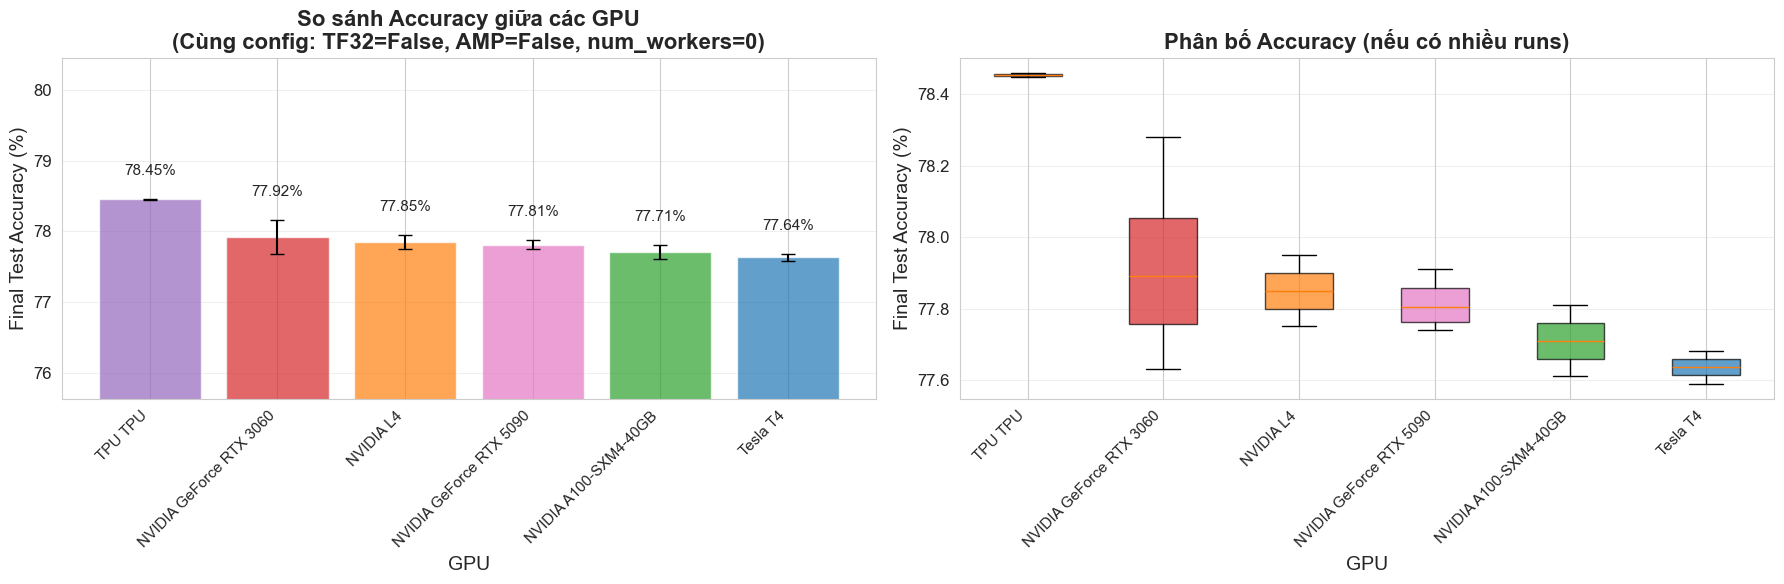

In [17]:
# Visualization: Bar chart và Box plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart: Mean accuracy
ax1 = axes[0]
colors = [GPU_COLORS.get(gpu, '#8c564b') for gpu in gpu_accuracy_df['GPU']]
bars = ax1.bar(gpu_accuracy_df['GPU'], gpu_accuracy_df['Mean'], 
               yerr=gpu_accuracy_df['Std'], capsize=5, color=colors, alpha=0.7)
ax1.set_ylabel('Final Test Accuracy (%)', fontsize=14)
ax1.set_xlabel('GPU', fontsize=14)
ax1.set_title('So sánh Accuracy giữa các GPU\n(Cùng config: TF32=False, AMP=False, num_workers=0)', 
              fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([gpu_accuracy_df['Mean'].min() - 2, gpu_accuracy_df['Mean'].max() + 2])

# Xoay và điều chỉnh label trên trục x để không bị dính
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=11)

# Thêm giá trị trên mỗi bar
for i, (bar, mean, std) in enumerate(zip(bars, gpu_accuracy_df['Mean'], gpu_accuracy_df['Std'])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + std + 0.3,
             f'{mean:.2f}%', ha='center', va='bottom', fontsize=11)

# Box plot: Phân bố accuracy
ax2 = axes[1]
box_data = [gpu_groups[gpu] for gpu in gpu_accuracy_df['GPU']]
bp = ax2.boxplot(box_data, labels=gpu_accuracy_df['GPU'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax2.set_ylabel('Final Test Accuracy (%)', fontsize=14)
ax2.set_xlabel('GPU', fontsize=14)
ax2.set_title('Phân bố Accuracy (nếu có nhiều runs)', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Xoay và điều chỉnh label trên trục x để không bị dính
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=11)

plt.tight_layout()
plt.savefig('results/blog_figures/gpu_accuracy_comparison.png', dpi=150, bbox_inches='tight')
print("\n✓ Đã lưu figure: results/blog_figures/gpu_accuracy_comparison.png")
plt.show()


## 3. Phân tích 2: Ảnh hưởng của Cấu hình đến Accuracy


In [6]:
def analyze_config_impact(results):
    """Phân tích ảnh hưởng của từng cấu hình đến accuracy"""
    config_analysis = {
        'TF32': defaultdict(list),
        'AMP': defaultdict(list),
        'num_workers': defaultdict(list),
        'cudnn_benchmark': defaultdict(list),
        'deterministic_algorithms': defaultdict(list)
    }
    
    for r in results:
        config = r.get('config', {})
        gpu_name = config.get('gpu_name', r.get('gpu_name', 'Unknown'))
        test_acc = r.get('test_acc', [])
        if not test_acc:
            continue
        
        final_acc = test_acc[-1]
        
        # TF32
        tf32 = config.get('tf32_enabled', r.get('tf32_enabled', False))
        config_analysis['TF32'][(gpu_name, tf32)].append(final_acc)
        
        # AMP
        amp = config.get('amp_enabled', r.get('amp_enabled', False))
        config_analysis['AMP'][(gpu_name, amp)].append(final_acc)
        
        # num_workers
        workers = config.get('num_workers', r.get('num_workers', 0))
        config_analysis['num_workers'][(gpu_name, workers)].append(final_acc)
        
        # cudnn_benchmark
        bench = config.get('cudnn_benchmark', False)
        config_analysis['cudnn_benchmark'][(gpu_name, bench)].append(final_acc)
        
        # deterministic_algorithms
        det = config.get('deterministic_algorithms', False)
        config_analysis['deterministic_algorithms'][(gpu_name, det)].append(final_acc)
    
    return config_analysis

config_impact = analyze_config_impact(deterministic_results)

# Tạo bảng so sánh cho từng config
def create_config_comparison_table(config_impact, config_name):
    """Tạo bảng so sánh cho một config cụ thể"""
    rows = []
    for (gpu, value), accs in config_impact[config_name].items():
        rows.append({
            'GPU': gpu,
            f'{config_name}': value,
            'Mean Accuracy': np.mean(accs),
            'Std': np.std(accs),
            'Count': len(accs)
        })
    return pd.DataFrame(rows)

print("="*80)
print("PHÂN TÍCH ẢNH HƯỞNG CỦA CẤU HÌNH")
print("="*80)

for config_name in ['TF32', 'AMP', 'num_workers', 'cudnn_benchmark', 'deterministic_algorithms']:
    df = create_config_comparison_table(config_impact, config_name)
    if len(df) > 0:
        print(f"\n{config_name}:")
        print(df.to_string(index=False))


PHÂN TÍCH ẢNH HƯỞNG CỦA CẤU HÌNH

TF32:
                    GPU  TF32  Mean Accuracy      Std  Count
  NVIDIA A100-SXM4-40GB False        76.9400 0.772684      5
  NVIDIA A100-SXM4-40GB  True        77.0700 0.000000      1
NVIDIA GeForce RTX 3060 False        77.9225 0.240663      4
NVIDIA GeForce RTX 3060  True        77.6100 0.000000      1
NVIDIA GeForce RTX 5090 False        77.7220 0.195079      5
NVIDIA GeForce RTX 5090  True        76.8500 0.000000      1
              NVIDIA L4 False        77.2060 0.903208      5
               Tesla T4 False        77.2240 0.548438      5
                TPU TPU False        77.5925 0.864852      4

AMP:
                    GPU   AMP  Mean Accuracy      Std  Count
  NVIDIA A100-SXM4-40GB False        76.9120 0.764890      5
  NVIDIA A100-SXM4-40GB  True        77.2100 0.000000      1
NVIDIA GeForce RTX 3060 False        77.8600 0.248918      5
NVIDIA GeForce RTX 5090 False        77.6220 0.390456      5
NVIDIA GeForce RTX 5090  True        77


✓ Đã lưu figure: results/blog_figures/config_impact_comparison.png


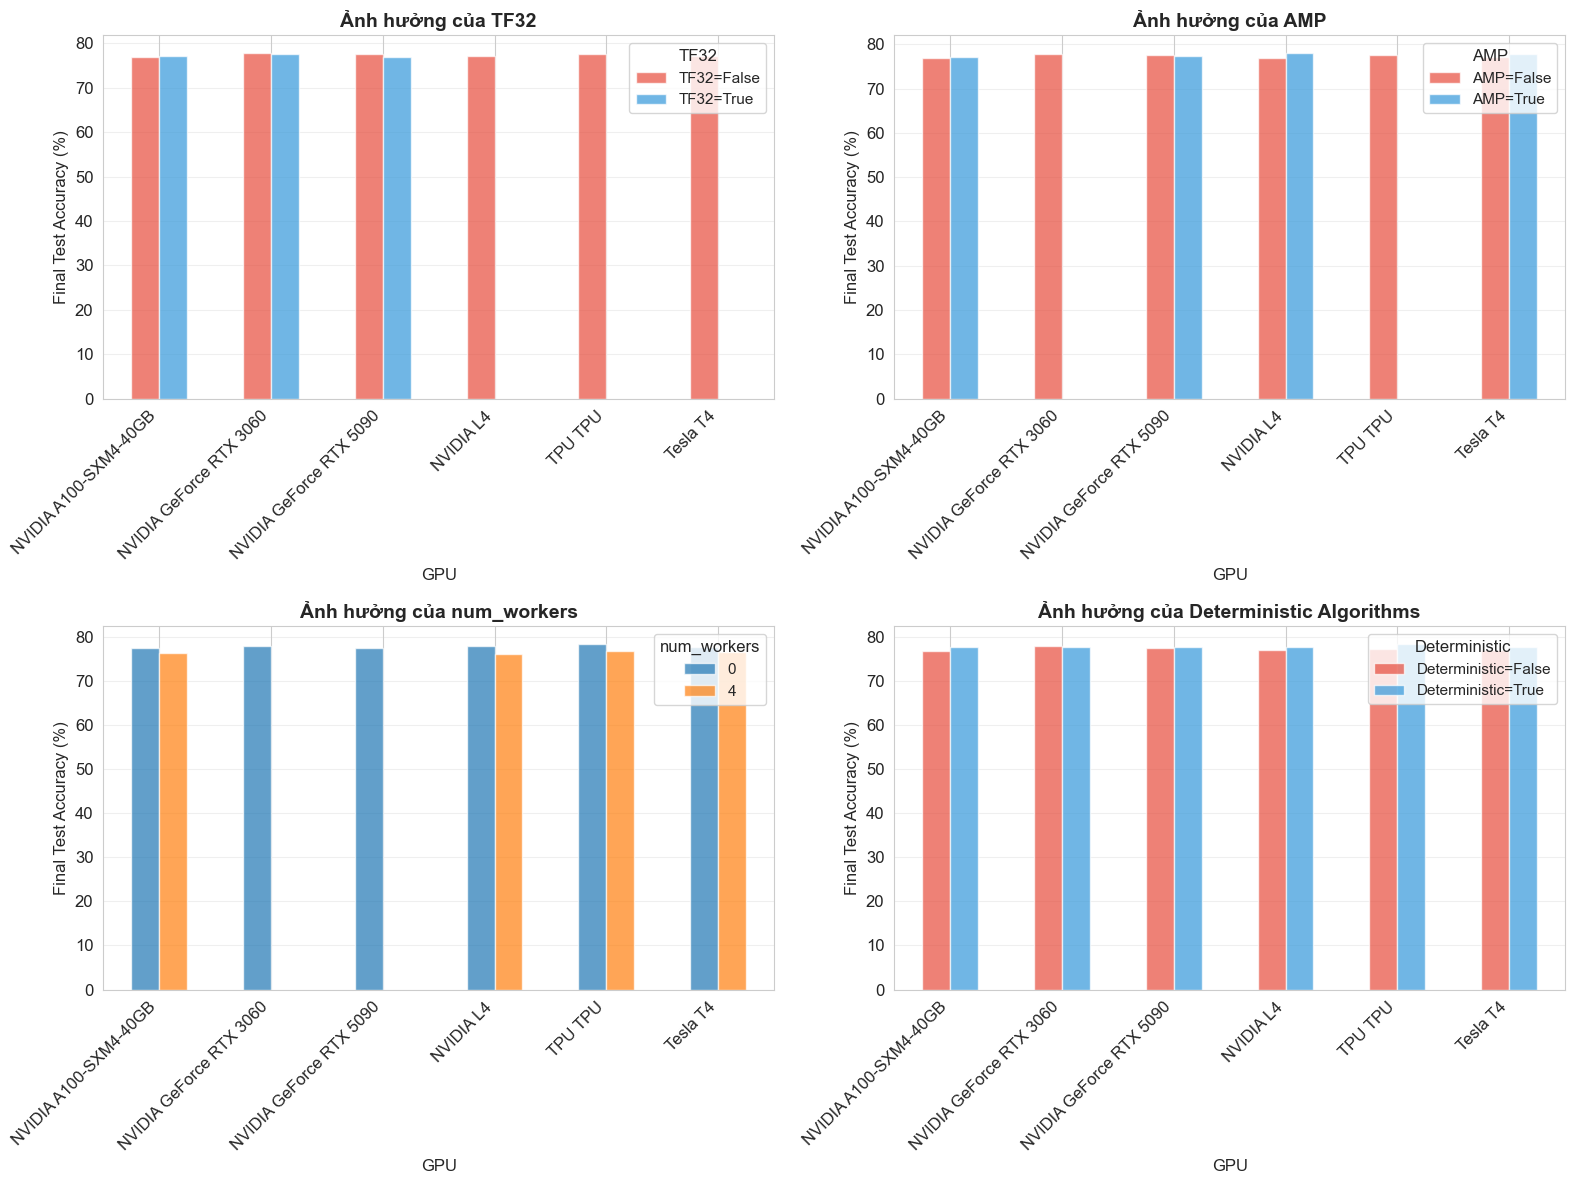

In [7]:
# Visualization: Grouped bar chart cho TF32 và AMP
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# TF32 Impact
ax1 = axes[0, 0]
tf32_df = create_config_comparison_table(config_impact, 'TF32')
if len(tf32_df) > 0:
    tf32_pivot = tf32_df.pivot(index='GPU', columns='TF32', values='Mean Accuracy')
    tf32_pivot.plot(kind='bar', ax=ax1, color=['#e74c3c', '#3498db'], alpha=0.7)
    ax1.set_ylabel('Final Test Accuracy (%)', fontsize=12)
    ax1.set_xlabel('GPU', fontsize=12)
    ax1.set_title('Ảnh hưởng của TF32', fontsize=14, fontweight='bold')
    ax1.legend(['TF32=False', 'TF32=True'], title='TF32')
    ax1.grid(True, alpha=0.3, axis='y')
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

# AMP Impact
ax2 = axes[0, 1]
amp_df = create_config_comparison_table(config_impact, 'AMP')
if len(amp_df) > 0:
    amp_pivot = amp_df.pivot(index='GPU', columns='AMP', values='Mean Accuracy')
    amp_pivot.plot(kind='bar', ax=ax2, color=['#e74c3c', '#3498db'], alpha=0.7)
    ax2.set_ylabel('Final Test Accuracy (%)', fontsize=12)
    ax2.set_xlabel('GPU', fontsize=12)
    ax2.set_title('Ảnh hưởng của AMP', fontsize=14, fontweight='bold')
    ax2.legend(['AMP=False', 'AMP=True'], title='AMP')
    ax2.grid(True, alpha=0.3, axis='y')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# num_workers Impact
ax3 = axes[1, 0]
workers_df = create_config_comparison_table(config_impact, 'num_workers')
if len(workers_df) > 0:
    workers_pivot = workers_df.pivot(index='GPU', columns='num_workers', values='Mean Accuracy')
    workers_pivot.plot(kind='bar', ax=ax3, alpha=0.7)
    ax3.set_ylabel('Final Test Accuracy (%)', fontsize=12)
    ax3.set_xlabel('GPU', fontsize=12)
    ax3.set_title('Ảnh hưởng của num_workers', fontsize=14, fontweight='bold')
    ax3.legend(title='num_workers')
    ax3.grid(True, alpha=0.3, axis='y')
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Deterministic algorithms Impact
ax4 = axes[1, 1]
det_df = create_config_comparison_table(config_impact, 'deterministic_algorithms')
if len(det_df) > 0:
    det_pivot = det_df.pivot(index='GPU', columns='deterministic_algorithms', values='Mean Accuracy')
    det_pivot.plot(kind='bar', ax=ax4, color=['#e74c3c', '#3498db'], alpha=0.7)
    ax4.set_ylabel('Final Test Accuracy (%)', fontsize=12)
    ax4.set_xlabel('GPU', fontsize=12)
    ax4.set_title('Ảnh hưởng của Deterministic Algorithms', fontsize=14, fontweight='bold')
    ax4.legend(['Deterministic=False', 'Deterministic=True'], title='Deterministic')
    ax4.grid(True, alpha=0.3, axis='y')
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('results/blog_figures/config_impact_comparison.png', dpi=150, bbox_inches='tight')
print("\n✓ Đã lưu figure: results/blog_figures/config_impact_comparison.png")
plt.show()



✓ Đã lưu figure: results/blog_figures/config_impact_heatmap.png


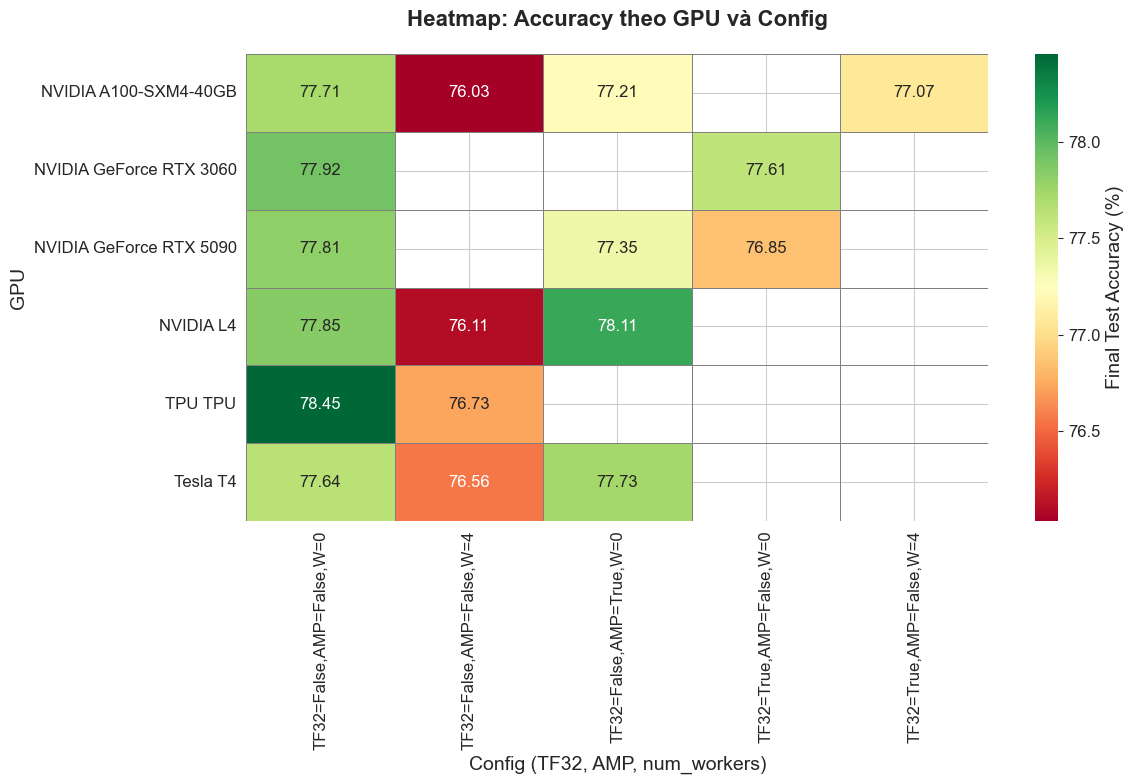

In [8]:
# Heatmap: Accuracy difference matrix
def create_accuracy_heatmap(results):
    """Tạo heatmap so sánh accuracy theo GPU và config"""
    # Nhóm theo GPU và config
    gpu_config_acc = defaultdict(lambda: defaultdict(list))
    
    for r in results:
        config = r.get('config', {})
        gpu_name = config.get('gpu_name', r.get('gpu_name', 'Unknown'))
        test_acc = r.get('test_acc', [])
        if not test_acc:
            continue
        
        final_acc = test_acc[-1]
        
        # Tạo config key
        tf32 = config.get('tf32_enabled', r.get('tf32_enabled', False))
        amp = config.get('amp_enabled', r.get('amp_enabled', False))
        workers = config.get('num_workers', r.get('num_workers', 0))
        config_key = f"TF32={tf32},AMP={amp},W={workers}"
        
        gpu_config_acc[gpu_name][config_key].append(final_acc)
    
    # Tính mean accuracy cho mỗi GPU-config
    heatmap_data = []
    gpus = sorted(set(gpu_config_acc.keys()))
    configs = set()
    for gpu in gpus:
        for config_key in gpu_config_acc[gpu].keys():
            configs.add(config_key)
    configs = sorted(configs)
    
    for gpu in gpus:
        row = []
        for config_key in configs:
            if config_key in gpu_config_acc[gpu]:
                mean_acc = np.mean(gpu_config_acc[gpu][config_key])
                row.append(mean_acc)
            else:
                row.append(np.nan)
        heatmap_data.append(row)
    
    df_heatmap = pd.DataFrame(heatmap_data, index=gpus, columns=configs)
    return df_heatmap

heatmap_df = create_accuracy_heatmap(deterministic_results)

if len(heatmap_df) > 0 and len(heatmap_df.columns) > 0:
    plt.figure(figsize=(max(12, len(heatmap_df.columns) * 1.5), max(8, len(heatmap_df) * 0.8)))
    sns.heatmap(heatmap_df, annot=True, fmt='.2f', cmap='RdYlGn', 
                cbar_kws={'label': 'Final Test Accuracy (%)'}, 
                linewidths=0.5, linecolor='gray')
    plt.title('Heatmap: Accuracy theo GPU và Config', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Config (TF32, AMP, num_workers)', fontsize=14)
    plt.ylabel('GPU', fontsize=14)
    plt.tight_layout()
    plt.savefig('results/blog_figures/config_impact_heatmap.png', dpi=150, bbox_inches='tight')
    print("\n✓ Đã lưu figure: results/blog_figures/config_impact_heatmap.png")
    plt.show()


## 4. Phân tích 3: Training Trajectory Comparison


In [9]:
def compare_trajectories(results, config_filter=None):
    """
    So sánh training trajectories giữa các GPU
    
    Returns:
        trajectories: Dict {gpu_name: {'train_loss': [...], 'test_acc': [...], ...}}
        metrics: Dict với correlation, convergence speed, stability
    """
    # Filter theo config
    filtered = results
    if config_filter:
        filtered = []
        for r in results:
            config = r.get('config', {})
            match = True
            for key, value in config_filter.items():
                if config.get(key) != value and r.get(key) != value:
                    match = False
                    break
            if match:
                filtered.append(r)
    
    # Nhóm theo GPU và tính mean trajectory (nếu có nhiều runs)
    gpu_trajectories = defaultdict(lambda: defaultdict(list))
    
    for r in filtered:
        config = r.get('config', {})
        gpu_name = config.get('gpu_name', r.get('gpu_name', 'Unknown'))
        
        for metric in ['train_loss', 'test_loss', 'train_acc', 'test_acc']:
            values = r.get(metric, [])
            if values:
                gpu_trajectories[gpu_name][metric].append(values)
    
    # Tính mean trajectory cho mỗi GPU
    trajectories = {}
    for gpu_name, metrics in gpu_trajectories.items():
        trajectories[gpu_name] = {}
        for metric, runs in metrics.items():
            # Tìm min length để align
            min_len = min(len(run) for run in runs)
            aligned_runs = [run[:min_len] for run in runs]
            mean_traj = np.mean(aligned_runs, axis=0)
            std_traj = np.std(aligned_runs, axis=0) if len(runs) > 1 else None
            trajectories[gpu_name][metric] = {
                'mean': mean_traj,
                'std': std_traj,
                'epochs': list(range(1, min_len + 1))
            }
    
    # Tính metrics: correlation, convergence, stability
    metrics = {}
    test_accs = {gpu: traj['test_acc']['mean'] for gpu, traj in trajectories.items() 
                 if 'test_acc' in traj}
    
    if len(test_accs) >= 2:
        gpus = list(test_accs.keys())
        correlations = []
        for i in range(len(gpus)):
            for j in range(i+1, len(gpus)):
                traj1 = test_accs[gpus[i]]
                traj2 = test_accs[gpus[j]]
                min_len = min(len(traj1), len(traj2))
                corr, _ = pearsonr(traj1[:min_len], traj2[:min_len])
                correlations.append({
                    'GPU1': gpus[i],
                    'GPU2': gpus[j],
                    'Correlation': corr
                })
        
        metrics['correlations'] = pd.DataFrame(correlations)
        
        # Convergence speed (epoch đạt 70% accuracy)
        convergence = []
        for gpu, traj in test_accs.items():
            epochs = trajectories[gpu]['test_acc']['epochs']
            for epoch, acc in zip(epochs, traj):
                if acc >= 70.0:
                    convergence.append({'GPU': gpu, 'Epoch_70pct': epoch})
                    break
        
        metrics['convergence'] = pd.DataFrame(convergence) if convergence else None
        
        # Stability (std của accuracy qua epochs)
        stability = []
        for gpu, traj in test_accs.items():
            std = np.std(traj)
            stability.append({'GPU': gpu, 'Std': std})
        metrics['stability'] = pd.DataFrame(stability)
    
    return trajectories, metrics

# So sánh trajectories với baseline config
trajectories, traj_metrics = compare_trajectories(deterministic_results, baseline_config)

print("="*80)
print("PHÂN TÍCH TRAINING TRAJECTORY")
print("="*80)

if traj_metrics.get('correlations') is not None and len(traj_metrics['correlations']) > 0:
    print("\nCorrelation giữa các GPU:")
    print(traj_metrics['correlations'].to_string(index=False))

if traj_metrics.get('convergence') is not None and len(traj_metrics['convergence']) > 0:
    print("\nConvergence Speed (Epoch đạt 70% accuracy):")
    print(traj_metrics['convergence'].to_string(index=False))

if traj_metrics.get('stability') is not None:
    print("\nStability (Std của accuracy qua epochs):")
    print(traj_metrics['stability'].to_string(index=False))


PHÂN TÍCH TRAINING TRAJECTORY

Correlation giữa các GPU:
                   GPU1                    GPU2  Correlation
  NVIDIA A100-SXM4-40GB NVIDIA GeForce RTX 3060     0.978761
  NVIDIA A100-SXM4-40GB NVIDIA GeForce RTX 5090     0.998198
  NVIDIA A100-SXM4-40GB               NVIDIA L4     0.998624
  NVIDIA A100-SXM4-40GB                Tesla T4     0.993397
  NVIDIA A100-SXM4-40GB                 TPU TPU     0.990335
NVIDIA GeForce RTX 3060 NVIDIA GeForce RTX 5090     0.985414
NVIDIA GeForce RTX 3060               NVIDIA L4     0.978624
NVIDIA GeForce RTX 3060                Tesla T4     0.988336
NVIDIA GeForce RTX 3060                 TPU TPU     0.990704
NVIDIA GeForce RTX 5090               NVIDIA L4     0.998710
NVIDIA GeForce RTX 5090                Tesla T4     0.994031
NVIDIA GeForce RTX 5090                 TPU TPU     0.993581
              NVIDIA L4                Tesla T4     0.993321
              NVIDIA L4                 TPU TPU     0.990149
               Tesla T4     


✓ Đã lưu figure: results/blog_figures/trajectory_comparison.png


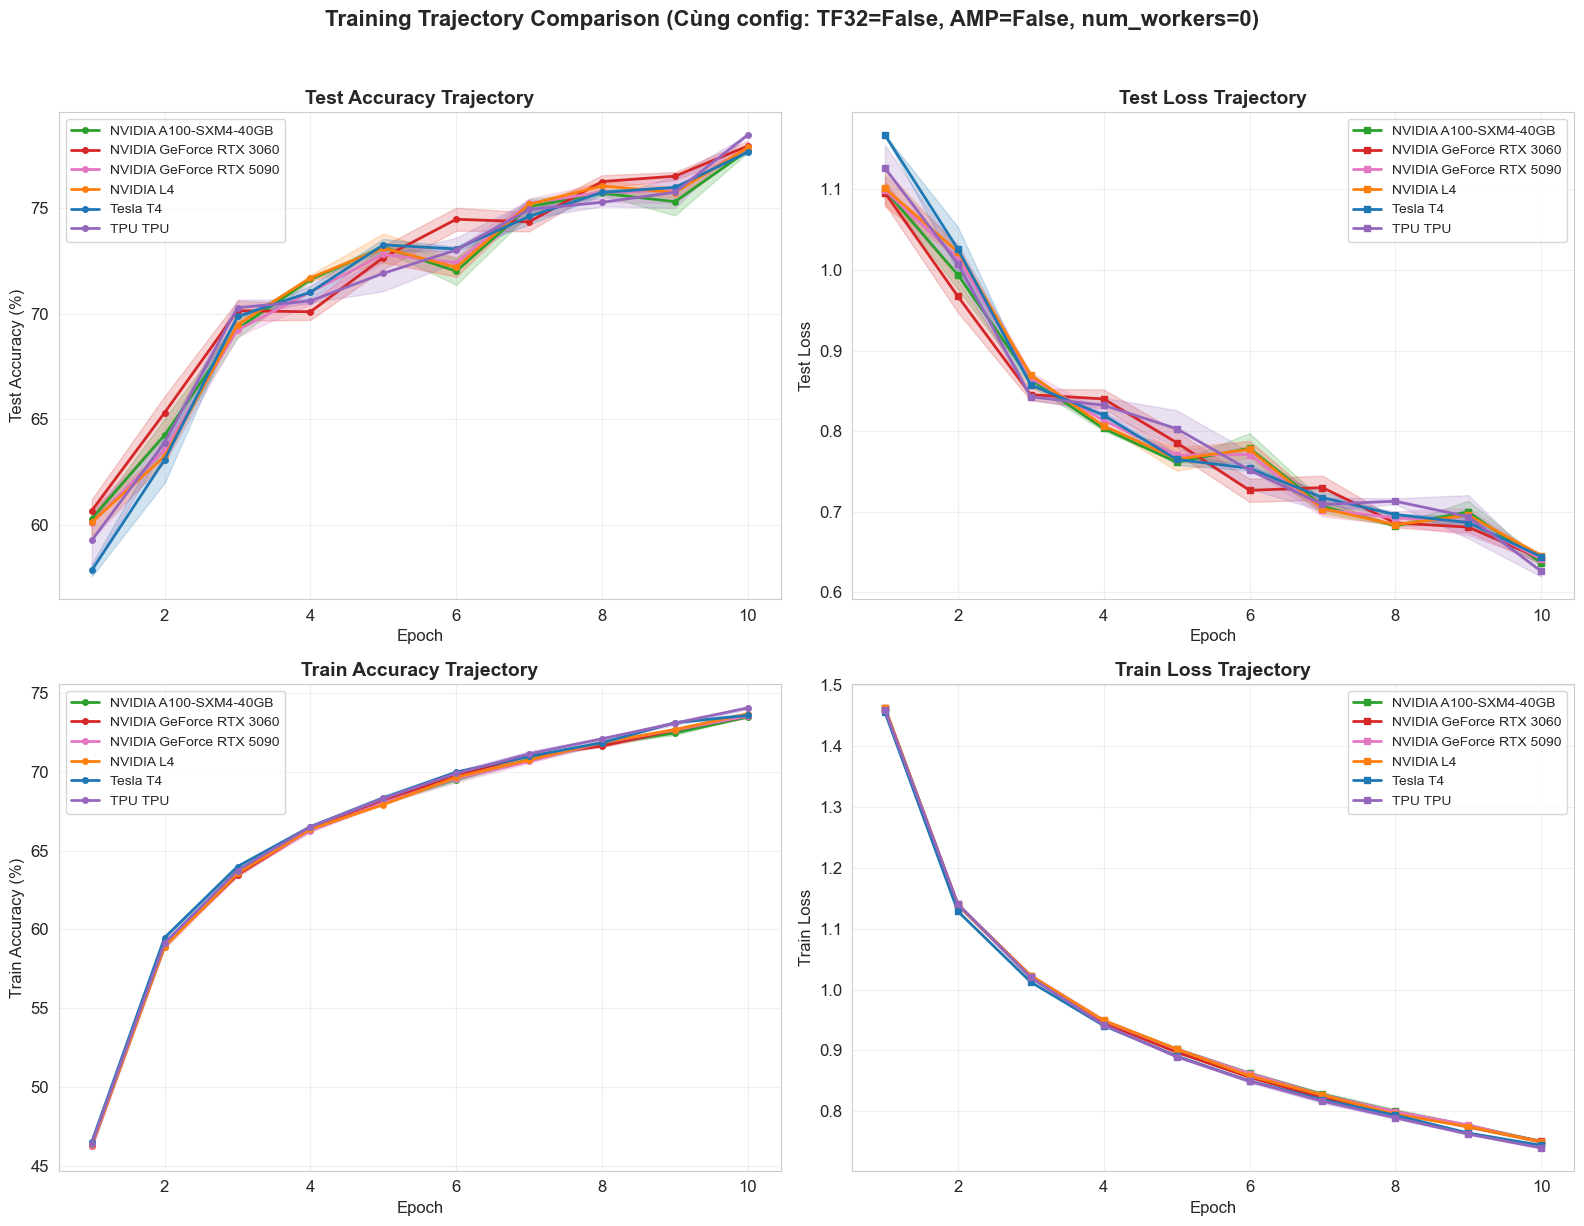

In [10]:
# Visualization: Training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Test Accuracy
ax1 = axes[0, 0]
for gpu_name, traj_data in trajectories.items():
    if 'test_acc' in traj_data:
        epochs = traj_data['test_acc']['epochs']
        mean_acc = traj_data['test_acc']['mean']
        std_acc = traj_data['test_acc']['std']
        color = GPU_COLORS.get(gpu_name, '#8c564b')
        
        ax1.plot(epochs, mean_acc, label=gpu_name, color=color, linewidth=2, marker='o', markersize=4)
        if std_acc is not None:
            ax1.fill_between(epochs, mean_acc - std_acc, mean_acc + std_acc, 
                           alpha=0.2, color=color)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
ax1.set_title('Test Accuracy Trajectory', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Test Loss
ax2 = axes[0, 1]
for gpu_name, traj_data in trajectories.items():
    if 'test_loss' in traj_data:
        epochs = traj_data['test_loss']['epochs']
        mean_loss = traj_data['test_loss']['mean']
        std_loss = traj_data['test_loss']['std']
        color = GPU_COLORS.get(gpu_name, '#8c564b')
        
        ax2.plot(epochs, mean_loss, label=gpu_name, color=color, linewidth=2, marker='s', markersize=4)
        if std_loss is not None:
            ax2.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, 
                           alpha=0.2, color=color)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Test Loss', fontsize=12)
ax2.set_title('Test Loss Trajectory', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Train Accuracy
ax3 = axes[1, 0]
for gpu_name, traj_data in trajectories.items():
    if 'train_acc' in traj_data:
        epochs = traj_data['train_acc']['epochs']
        mean_acc = traj_data['train_acc']['mean']
        std_acc = traj_data['train_acc']['std']
        color = GPU_COLORS.get(gpu_name, '#8c564b')
        
        ax3.plot(epochs, mean_acc, label=gpu_name, color=color, linewidth=2, marker='o', markersize=4)
        if std_acc is not None:
            ax3.fill_between(epochs, mean_acc - std_acc, mean_acc + std_acc, 
                           alpha=0.2, color=color)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Train Accuracy (%)', fontsize=12)
ax3.set_title('Train Accuracy Trajectory', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# Train Loss
ax4 = axes[1, 1]
for gpu_name, traj_data in trajectories.items():
    if 'train_loss' in traj_data:
        epochs = traj_data['train_loss']['epochs']
        mean_loss = traj_data['train_loss']['mean']
        std_loss = traj_data['train_loss']['std']
        color = GPU_COLORS.get(gpu_name, '#8c564b')
        
        ax4.plot(epochs, mean_loss, label=gpu_name, color=color, linewidth=2, marker='s', markersize=4)
        if std_loss is not None:
            ax4.fill_between(epochs, mean_loss - std_loss, mean_loss + std_loss, 
                           alpha=0.2, color=color)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Train Loss', fontsize=12)
ax4.set_title('Train Loss Trajectory', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

plt.suptitle('Training Trajectory Comparison (Cùng config: TF32=False, AMP=False, num_workers=0)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results/blog_figures/trajectory_comparison.png', dpi=150, bbox_inches='tight')
print("\n✓ Đã lưu figure: results/blog_figures/trajectory_comparison.png")
plt.show()


## 5. Phân tích 4: Optimizer Sensitivity


In [11]:
def analyze_optimizer_sensitivity(results):
    """Phân tích ảnh hưởng của optimizer đến accuracy"""
    optimizer_data = defaultdict(lambda: defaultdict(list))
    
    for r in results:
        optimizer = r.get('optimizer', 'Unknown')
        gpu_name = r.get('gpu_name', 'Unknown')
        config = r.get('config', {})
        if config:
            gpu_name = config.get('gpu_name', gpu_name)
        
        test_acc = r.get('test_acc', [])
        if test_acc:
            final_acc = test_acc[-1]
            optimizer_data[gpu_name][optimizer].append(final_acc)
    
    # Tính thống kê
    stats = []
    for gpu_name, optimizers in optimizer_data.items():
        for optimizer, accs in optimizers.items():
            stats.append({
                'GPU': gpu_name,
                'Optimizer': optimizer,
                'Mean Accuracy': np.mean(accs),
                'Std': np.std(accs),
                'Count': len(accs)
            })
    
    df = pd.DataFrame(stats)
    return df, optimizer_data

optimizer_df, optimizer_data = analyze_optimizer_sensitivity(optimizer_results)

print("="*80)
print("PHÂN TÍCH OPTIMIZER SENSITIVITY")
print("="*80)
if len(optimizer_df) > 0:
    print(optimizer_df.to_string(index=False))
else:
    print("Không có dữ liệu optimizer")


PHÂN TÍCH OPTIMIZER SENSITIVITY
                    GPU Optimizer  Mean Accuracy  Std  Count
  NVIDIA A100-SXM4-40GB      Adam          76.00  0.0      1
  NVIDIA A100-SXM4-40GB   RMSprop          70.33  0.0      1
  NVIDIA A100-SXM4-40GB       SGD          68.88  0.0      1
              NVIDIA L4      Adam          76.27  0.0      1
              NVIDIA L4   RMSprop          73.27  0.0      1
              NVIDIA L4       SGD          68.70  0.0      1
NVIDIA GeForce RTX 3060      Adam          77.29  0.0      1
NVIDIA GeForce RTX 3060   RMSprop          70.62  0.0      1
NVIDIA GeForce RTX 3060       SGD          69.46  0.0      1
NVIDIA GeForce RTX 5090      Adam          77.38  0.0      1
NVIDIA GeForce RTX 5090   RMSprop          73.35  0.0      1
NVIDIA GeForce RTX 5090       SGD          68.71  0.0      1
               Tesla T4      Adam          75.82  0.0      1
               Tesla T4   RMSprop          73.15  0.0      1
               Tesla T4       SGD          69.77  0.0


✓ Đã lưu figure: results/blog_figures/optimizer_sensitivity.png


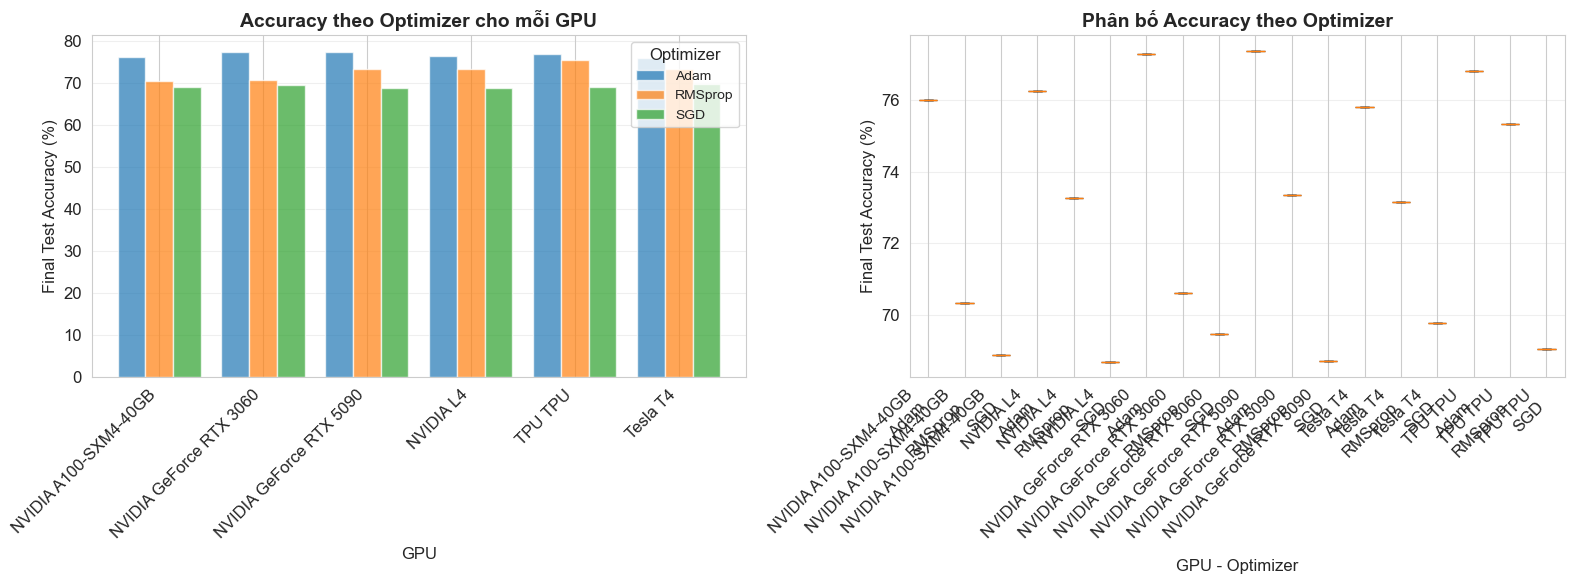

✓ Đã lưu figure: results/blog_figures/optimizer_trajectories.png


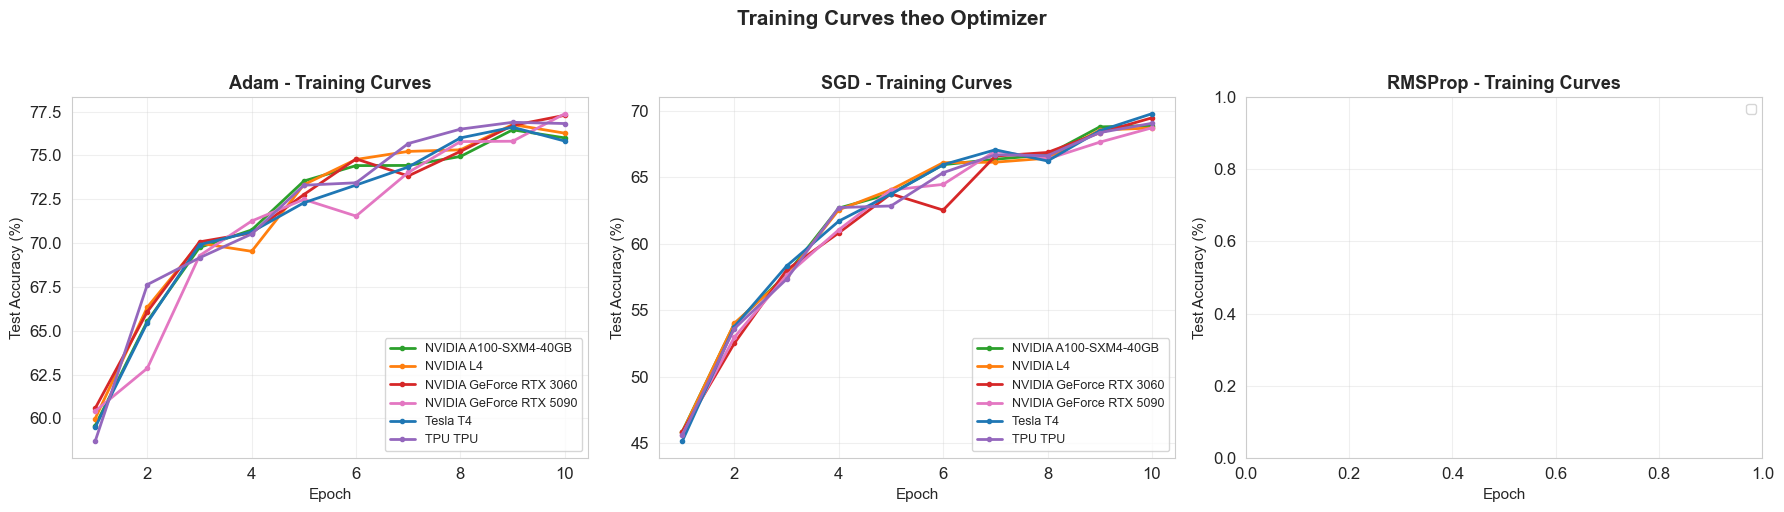

In [12]:
# Visualization: Optimizer sensitivity
if len(optimizer_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Grouped bar chart
    ax1 = axes[0]
    optimizer_pivot = optimizer_df.pivot(index='GPU', columns='Optimizer', values='Mean Accuracy')
    optimizer_pivot.plot(kind='bar', ax=ax1, alpha=0.7, width=0.8)
    ax1.set_ylabel('Final Test Accuracy (%)', fontsize=12)
    ax1.set_xlabel('GPU', fontsize=12)
    ax1.set_title('Accuracy theo Optimizer cho mỗi GPU', fontsize=14, fontweight='bold')
    ax1.legend(title='Optimizer', fontsize=10)
    ax1.grid(True, alpha=0.3, axis='y')
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Box plot
    ax2 = axes[1]
    box_data = []
    labels = []
    for gpu_name in optimizer_df['GPU'].unique():
        for optimizer in optimizer_df['Optimizer'].unique():
            subset = optimizer_df[(optimizer_df['GPU'] == gpu_name) & 
                                 (optimizer_df['Optimizer'] == optimizer)]
            if len(subset) > 0 and gpu_name in optimizer_data and optimizer in optimizer_data[gpu_name]:
                box_data.append(optimizer_data[gpu_name][optimizer])
                labels.append(f"{gpu_name}\n{optimizer}")
    
    if box_data:
        bp = ax2.boxplot(box_data, labels=labels, patch_artist=True)
        for patch in bp['boxes']:
            patch.set_facecolor('#3498db')
            patch.set_alpha(0.7)
        ax2.set_ylabel('Final Test Accuracy (%)', fontsize=12)
        ax2.set_xlabel('GPU - Optimizer', fontsize=12)
        ax2.set_title('Phân bố Accuracy theo Optimizer', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    plt.tight_layout()
    plt.savefig('results/blog_figures/optimizer_sensitivity.png', dpi=150, bbox_inches='tight')
    print("\n✓ Đã lưu figure: results/blog_figures/optimizer_sensitivity.png")
    plt.show()
    
    # So sánh training curves cho từng optimizer
    if len(optimizer_results) > 0:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        optimizers = ['Adam', 'SGD', 'RMSProp']
        for idx, optimizer in enumerate(optimizers):
            ax = axes[idx]
            optimizer_trajs = []
            for r in optimizer_results:
                if r.get('optimizer') == optimizer:
                    gpu_name = r.get('gpu_name', 'Unknown')
                    test_acc = r.get('test_acc', [])
                    if test_acc:
                        epochs = list(range(1, len(test_acc) + 1))
                        color = GPU_COLORS.get(gpu_name, '#8c564b')
                        ax.plot(epochs, test_acc, label=gpu_name, color=color, 
                               linewidth=2, marker='o', markersize=3)
            
            ax.set_xlabel('Epoch', fontsize=11)
            ax.set_ylabel('Test Accuracy (%)', fontsize=11)
            ax.set_title(f'{optimizer} - Training Curves', fontsize=13, fontweight='bold')
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)
        
        plt.suptitle('Training Curves theo Optimizer', fontsize=15, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig('results/blog_figures/optimizer_trajectories.png', dpi=150, bbox_inches='tight')
        print("✓ Đã lưu figure: results/blog_figures/optimizer_trajectories.png")
        plt.show()


## 6. Phân tích 5: Statistical vs Bit-exact Reproducibility


In [13]:
def analyze_reproducibility(results, config_filter=None):
    """
    Phân tích Statistical vs Bit-exact Reproducibility
    
    Returns:
        reproducibility_df: DataFrame với categorization
    """
    # Filter theo config
    filtered = results
    if config_filter:
        filtered = []
        for r in results:
            config = r.get('config', {})
            match = True
            for key, value in config_filter.items():
                if config.get(key) != value and r.get(key) != value:
                    match = False
                    break
            if match:
                filtered.append(r)
    
    # Nhóm theo config (không tính GPU name)
    config_groups = defaultdict(list)
    for r in filtered:
        config = r.get('config', {})
        seed = r.get('seed', 'unknown')
        tf32 = config.get('tf32_enabled', r.get('tf32_enabled', False))
        amp = config.get('amp_enabled', r.get('amp_enabled', False))
        workers = config.get('num_workers', r.get('num_workers', 0))
        config_key = f"seed_{seed}_tf32_{tf32}_amp_{amp}_w{workers}"
        config_groups[config_key].append(r)
    
    reproducibility_data = []
    
    for config_key, group_results in config_groups.items():
        if len(group_results) < 2:
            continue
        
        # Lấy test accuracy
        test_accs = []
        trajectories = []
        gpus = []
        
        for r in group_results:
            test_acc = r.get('test_acc', [])
            if test_acc:
                final_acc = test_acc[-1]
                test_accs.append(final_acc)
                trajectories.append(test_acc)
                config = r.get('config', {})
                gpu_name = config.get('gpu_name', r.get('gpu_name', 'Unknown'))
                gpus.append(gpu_name)
        
        if len(test_accs) < 2:
            continue
        
        # Tính metrics
        mean_acc = np.mean(test_accs)
        std_acc = np.std(test_accs)
        min_acc = np.min(test_accs)
        max_acc = np.max(test_accs)
        max_diff = max_acc - min_acc
        
        # Tính correlation giữa trajectories
        correlations = []
        for i in range(len(trajectories)):
            for j in range(i+1, len(trajectories)):
                min_len = min(len(trajectories[i]), len(trajectories[j]))
                corr, _ = pearsonr(trajectories[i][:min_len], trajectories[j][:min_len])
                correlations.append(corr)
        
        mean_corr = np.mean(correlations) if correlations else 0.0
        
        # Phân loại
        if max_diff < 0.01:
            category = "Bit-exact"
        elif max_diff < 0.5 and mean_corr > 0.99:
            category = "Statistical (Tốt)"
        elif max_diff < 2.0 and mean_corr > 0.95:
            category = "Statistical (Chấp nhận)"
        else:
            category = "Có vấn đề"
        
        reproducibility_data.append({
            'Config': config_key,
            'Num_GPUs': len(set(gpus)),
            'Mean_Accuracy': mean_acc,
            'Std_Accuracy': std_acc,
            'Min_Accuracy': min_acc,
            'Max_Accuracy': max_acc,
            'Max_Diff': max_diff,
            'Mean_Correlation': mean_corr,
            'Category': category,
            'GPUs': ', '.join(set(gpus))
        })
    
    df = pd.DataFrame(reproducibility_data)
    return df

reproducibility_df = analyze_reproducibility(deterministic_results, baseline_config)

print("="*80)
print("PHÂN TÍCH STATISTICAL VS BIT-EXACT REPRODUCIBILITY")
print("="*80)
if len(reproducibility_df) > 0:
    print(reproducibility_df[['Config', 'Num_GPUs', 'Mean_Accuracy', 'Max_Diff', 
                              'Mean_Correlation', 'Category', 'GPUs']].to_string(index=False))
else:
    print("Không có đủ dữ liệu để phân tích")


PHÂN TÍCH STATISTICAL VS BIT-EXACT REPRODUCIBILITY
                         Config  Num_GPUs  Mean_Accuracy  Max_Diff  Mean_Correlation                Category                                                                                                  GPUs
seed_42_tf32_False_amp_False_w0         6      77.890625      0.87          0.985069 Statistical (Chấp nhận) Tesla T4, NVIDIA L4, NVIDIA GeForce RTX 3060, NVIDIA GeForce RTX 5090, TPU TPU, NVIDIA A100-SXM4-40GB



✓ Đã lưu figure: results/blog_figures/reproducibility_analysis.png


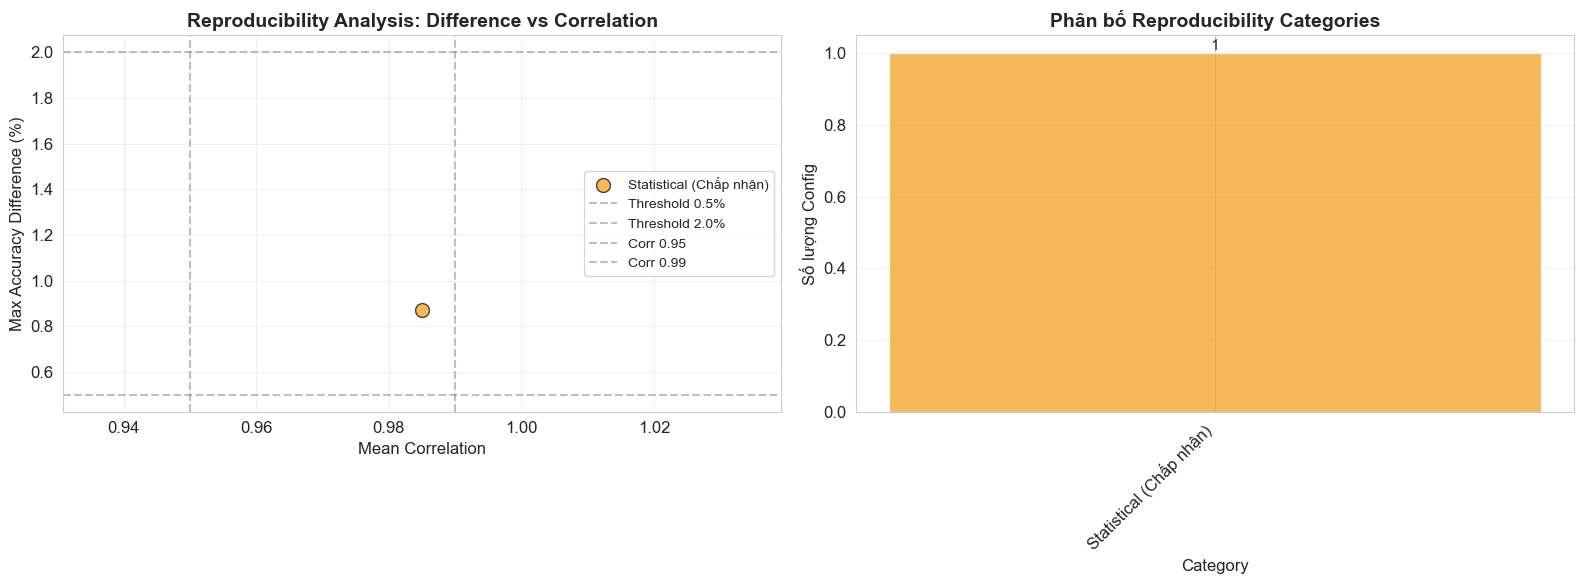


REPRODUCIBILITY SUMMARY TABLE
                         Config  Num_GPUs  Max_Diff  Mean_Correlation                Category
seed_42_tf32_False_amp_False_w0         6      0.87          0.985069 Statistical (Chấp nhận)


In [14]:
# Visualization: Reproducibility analysis
if len(reproducibility_df) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter plot: Max Difference vs Correlation
    ax1 = axes[0]
    categories = reproducibility_df['Category'].unique()
    colors_map = {
        'Bit-exact': '#2ecc71',
        'Statistical (Tốt)': '#3498db',
        'Statistical (Chấp nhận)': '#f39c12',
        'Có vấn đề': '#e74c3c'
    }
    
    for category in categories:
        subset = reproducibility_df[reproducibility_df['Category'] == category]
        color = colors_map.get(category, '#8c564b')
        ax1.scatter(subset['Mean_Correlation'], subset['Max_Diff'], 
                   label=category, color=color, s=100, alpha=0.7, edgecolors='black', linewidth=1)
    
    ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Threshold 0.5%')
    ax1.axhline(y=2.0, color='gray', linestyle='--', alpha=0.5, label='Threshold 2.0%')
    ax1.axvline(x=0.95, color='gray', linestyle='--', alpha=0.5, label='Corr 0.95')
    ax1.axvline(x=0.99, color='gray', linestyle='--', alpha=0.5, label='Corr 0.99')
    
    ax1.set_xlabel('Mean Correlation', fontsize=12)
    ax1.set_ylabel('Max Accuracy Difference (%)', fontsize=12)
    ax1.set_title('Reproducibility Analysis: Difference vs Correlation', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Bar chart: Distribution of categories
    ax2 = axes[1]
    category_counts = reproducibility_df['Category'].value_counts()
    colors_bar = [colors_map.get(cat, '#8c564b') for cat in category_counts.index]
    bars = ax2.bar(category_counts.index, category_counts.values, color=colors_bar, alpha=0.7)
    ax2.set_ylabel('Số lượng Config', fontsize=12)
    ax2.set_xlabel('Category', fontsize=12)
    ax2.set_title('Phân bố Reproducibility Categories', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Thêm số trên mỗi bar
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('results/blog_figures/reproducibility_analysis.png', dpi=150, bbox_inches='tight')
    print("\n✓ Đã lưu figure: results/blog_figures/reproducibility_analysis.png")
    plt.show()
    
    # Tạo table với color coding
    print("\n" + "="*80)
    print("REPRODUCIBILITY SUMMARY TABLE")
    print("="*80)
    display_df = reproducibility_df[['Config', 'Num_GPUs', 'Max_Diff', 'Mean_Correlation', 'Category']].copy()
    print(display_df.to_string(index=False))


## 7. Export Results cho Blog


In [15]:
def export_blog_summary():
    """Tạo markdown summary với key findings"""
    summary_lines = []
    summary_lines.append("# Phân tích Ảnh hưởng của Khác biệt GPU đến Tính chính xác Mô hình\n")
    summary_lines.append("## Key Findings\n")
    
    # 1. GPU Accuracy Comparison
    if len(gpu_accuracy_df) > 0:
        summary_lines.append("### 1. So sánh Accuracy giữa các GPU\n")
        summary_lines.append("Với cùng config (TF32=False, AMP=False, num_workers=0):\n")
        for _, row in gpu_accuracy_df.iterrows():
            summary_lines.append(f"- **{row['GPU']}**: {row['Mean']:.2f}% (std: {row['Std']:.2f}%)")
        summary_lines.append("")
    
    # 2. Config Impact
    summary_lines.append("### 2. Ảnh hưởng của Cấu hình\n")
    summary_lines.append("Các yếu tố ảnh hưởng đến accuracy:\n")
    summary_lines.append("- **TF32**: Ảnh hưởng khác nhau tùy GPU (chỉ GPU Ampere+ hỗ trợ)")
    summary_lines.append("- **AMP**: Có thể ảnh hưởng đến accuracy và reproducibility")
    summary_lines.append("- **num_workers**: Ảnh hưởng nhỏ đến accuracy nhưng có thể ảnh hưởng reproducibility")
    summary_lines.append("- **Deterministic algorithms**: Giúp cải thiện reproducibility")
    summary_lines.append("")
    
    # 3. Optimizer Sensitivity
    if len(optimizer_df) > 0:
        summary_lines.append("### 3. Optimizer Sensitivity\n")
        summary_lines.append("Các optimizer khác nhau có độ nhạy cảm khác nhau với floating-point differences:\n")
        for optimizer in optimizer_df['Optimizer'].unique():
            subset = optimizer_df[optimizer_df['Optimizer'] == optimizer]
            mean_acc = subset['Mean Accuracy'].mean()
            summary_lines.append(f"- **{optimizer}**: Mean accuracy = {mean_acc:.2f}%")
        summary_lines.append("")
    
    # 4. Reproducibility
    if len(reproducibility_df) > 0:
        summary_lines.append("### 4. Statistical vs Bit-exact Reproducibility\n")
        category_counts = reproducibility_df['Category'].value_counts()
        summary_lines.append("Phân loại kết quả:\n")
        for category, count in category_counts.items():
            summary_lines.append(f"- **{category}**: {count} config(s)")
        summary_lines.append("")
        summary_lines.append("**Kết luận**:")
        summary_lines.append("- Bit-exact reproducibility rất khó đạt được trên GPU khác nhau")
        summary_lines.append("- Statistical reproducibility là mục tiêu thực tế")
        summary_lines.append("- Cần so sánh xu hướng (trend) thay vì giá trị tuyệt đối")
        summary_lines.append("")
    
    # 5. Recommendations
    summary_lines.append("### 5. Khuyến nghị\n")
    summary_lines.append("1. **So sánh xu hướng**: Quan trọng hơn so sánh giá trị tuyệt đối")
    summary_lines.append("2. **Ghi rõ GPU + precision**: Trong báo cáo thực nghiệm")
    summary_lines.append("3. **Không debug chỉ dựa trên accuracy**: Cần xem training trajectory")
    summary_lines.append("4. **Sử dụng deterministic config**: Khi cần reproducibility cao")
    summary_lines.append("")
    
    summary_text = "\n".join(summary_lines)
    
    # Lưu file
    with open('results/blog_analysis_summary.md', 'w', encoding='utf-8') as f:
        f.write(summary_text)
    
    print("✓ Đã lưu summary: results/blog_analysis_summary.md")
    return summary_text

# Export summary
summary = export_blog_summary()
print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(summary)


✓ Đã lưu summary: results/blog_analysis_summary.md

SUMMARY
# Phân tích Ảnh hưởng của Khác biệt GPU đến Tính chính xác Mô hình

## Key Findings

### 1. So sánh Accuracy giữa các GPU

Với cùng config (TF32=False, AMP=False, num_workers=0):

- **TPU TPU**: 78.45% (std: 0.00%)
- **NVIDIA GeForce RTX 3060**: 77.92% (std: 0.24%)
- **NVIDIA L4**: 77.85% (std: 0.10%)
- **NVIDIA GeForce RTX 5090**: 77.81% (std: 0.07%)
- **NVIDIA A100-SXM4-40GB**: 77.71% (std: 0.10%)
- **Tesla T4**: 77.64% (std: 0.05%)

### 2. Ảnh hưởng của Cấu hình

Các yếu tố ảnh hưởng đến accuracy:

- **TF32**: Ảnh hưởng khác nhau tùy GPU (chỉ GPU Ampere+ hỗ trợ)
- **AMP**: Có thể ảnh hưởng đến accuracy và reproducibility
- **num_workers**: Ảnh hưởng nhỏ đến accuracy nhưng có thể ảnh hưởng reproducibility
- **Deterministic algorithms**: Giúp cải thiện reproducibility

### 3. Optimizer Sensitivity

Các optimizer khác nhau có độ nhạy cảm khác nhau với floating-point differences:

- **Adam**: Mean accuracy = 76.60%
- **RMSprop*

In [16]:
# Export các bảng quan trọng ra CSV
if len(gpu_accuracy_df) > 0:
    gpu_accuracy_df.to_csv('results/blog_figures/gpu_accuracy_comparison.csv', index=False)
    print("✓ Đã lưu: results/blog_figures/gpu_accuracy_comparison.csv")

if len(optimizer_df) > 0:
    optimizer_df.to_csv('results/blog_figures/optimizer_sensitivity.csv', index=False)
    print("✓ Đã lưu: results/blog_figures/optimizer_sensitivity.csv")

if len(reproducibility_df) > 0:
    reproducibility_df.to_csv('results/blog_figures/reproducibility_analysis.csv', index=False)
    print("✓ Đã lưu: results/blog_figures/reproducibility_analysis.csv")

print("\n" + "="*80)
print("HOÀN TẤT PHÂN TÍCH")
print("="*80)
print("Tất cả figures và summaries đã được lưu vào thư mục: results/blog_figures/")
print("Các file quan trọng:")
print("  - gpu_accuracy_comparison.png")
print("  - config_impact_comparison.png")
print("  - config_impact_heatmap.png")
print("  - trajectory_comparison.png")
print("  - optimizer_sensitivity.png")
print("  - optimizer_trajectories.png")
print("  - reproducibility_analysis.png")
print("  - blog_analysis_summary.md")


✓ Đã lưu: results/blog_figures/gpu_accuracy_comparison.csv
✓ Đã lưu: results/blog_figures/optimizer_sensitivity.csv
✓ Đã lưu: results/blog_figures/reproducibility_analysis.csv

HOÀN TẤT PHÂN TÍCH
Tất cả figures và summaries đã được lưu vào thư mục: results/blog_figures/
Các file quan trọng:
  - gpu_accuracy_comparison.png
  - config_impact_comparison.png
  - config_impact_heatmap.png
  - trajectory_comparison.png
  - optimizer_sensitivity.png
  - optimizer_trajectories.png
  - reproducibility_analysis.png
  - blog_analysis_summary.md
